In [3]:
import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


import matplotlib.font_manager


def data_analysis(combined_data):
    number_of_betas = len(combined_data)
    recordings, x_dim, y_dim, z_dim = combined_data['backup_data'][0].shape

    time_series = np.zeros((number_of_betas, recordings, 2))
    david_data = np.zeros(number_of_betas)
    tin_data = np.zeros(number_of_betas)

    betas = combined_data["reboot_seed"]["experiment_parameters"]["beta"]
    z_order = combined_data["reboot_seed"]["experiment_parameters"]["z_order"][0]
    roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])

    for (i, data_step) in enumerate(combined_data):
        print(i)
        loops = data_step['backup_data']
        loops = roots_of_unity[loops]

        spacial_dimensions = x_dim * y_dim * z_dim
        normalization = loops[..., 0].size

        # Time series
        temp = loops[...].sum(axis=(1, 2, 3)) / spacial_dimensions
        time_series[i] = temp

        # Tin Data
        temp = loops.sum(axis=(1, 2, 3))
        tin_snapshot = np.linalg.norm(temp, axis=-1).sum()
        tin_data[i] = tin_snapshot/normalization

        # David data
        temp = loops[:, :, :, :, :].sum(axis=0)
        david_snapshot = np.linalg.norm(temp, axis=-1).sum()
        david_data[i] = david_snapshot/normalization

    return betas, time_series, tin_data, david_data


load_data = True

if not load_data:
    data = np.load('../../../../_recordings/CLUSTER-2024-04-23--08-17-20/archive.npz')
    sorted_list = sorted(
        data.values(), key=lambda x: x["run_info"]["run_id"][0])

    shape = sorted_list[0]['reboot_seed']['experiment_parameters']['shape'][0]
    chunk_size = 0
    for data in sorted_list:
        if np.array_equal(shape, data['reboot_seed']['experiment_parameters']['shape'][0]):
            chunk_size += 1
        else:
            break

    all_data = [sorted_list[i:i+chunk_size]
                for i in range(0, len(sorted_list), chunk_size)]
    combined = []
    for data in all_data:
        combined.append(np.concatenate(data))

    betas_list = []
    tin_data_list = []
    david_data_list = []
    time_series_list = []
    shapes_list = []

    for data in combined:
        betas, time_series, tin_data, david_data = data_analysis(data)
        betas_list.append(betas)
        tin_data_list.append(tin_data)
        david_data_list.append(david_data)
        time_series_list.append(time_series)
        shapes_list.append(data[0]['reboot_seed']
                           ['experiment_parameters']['shape'][0])

    print(shapes_list)

    # Save the betas time_series, tin_data, david_data
    np.savez('finite_scale_triangle.npz',
             betas_list=betas_list, tin_data_list=tin_data_list, david_data_list=david_data_list, time_series_list=time_series_list, shapes_list=shapes_list)


else:
    print("Loading data")
    data = np.load('finite_scale_triangle.npz')

    betas_list = data['betas_list']
    tin_data_list = data['tin_data_list']
    david_data_list = data['david_data_list']
    time_series_list = data['time_series_list']
    shapes_list = data['shapes_list']


# # Draw David Data and Tin Data, draw time series
# fig, ax = plt.subplots(1, 1)

# cmap = plt.cm.viridis  # You can choose any other colormap
# norm = Normalize(vmin=0, vmax=6)
# sm = ScalarMappable(norm=norm, cmap=cmap)

# for (i, (betas, tin_data, david_data)) in enumerate(zip(betas_list, tin_data_list, david_data_list)):
#     print(i)
#     color = sm.to_rgba(i)
#     ax.plot(betas, tin_data, '-o', color=color,
#             label=r"$L={}$".format(shapes_list[i]))

# ax.legend(loc='best')
# ax.set_xlabel(r"$\beta$")

# plt.savefig(
#     'z_n_gauge/data_analysis/figs/triangle_to_circle/average_plaquette.pdf')




Loading data


[18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


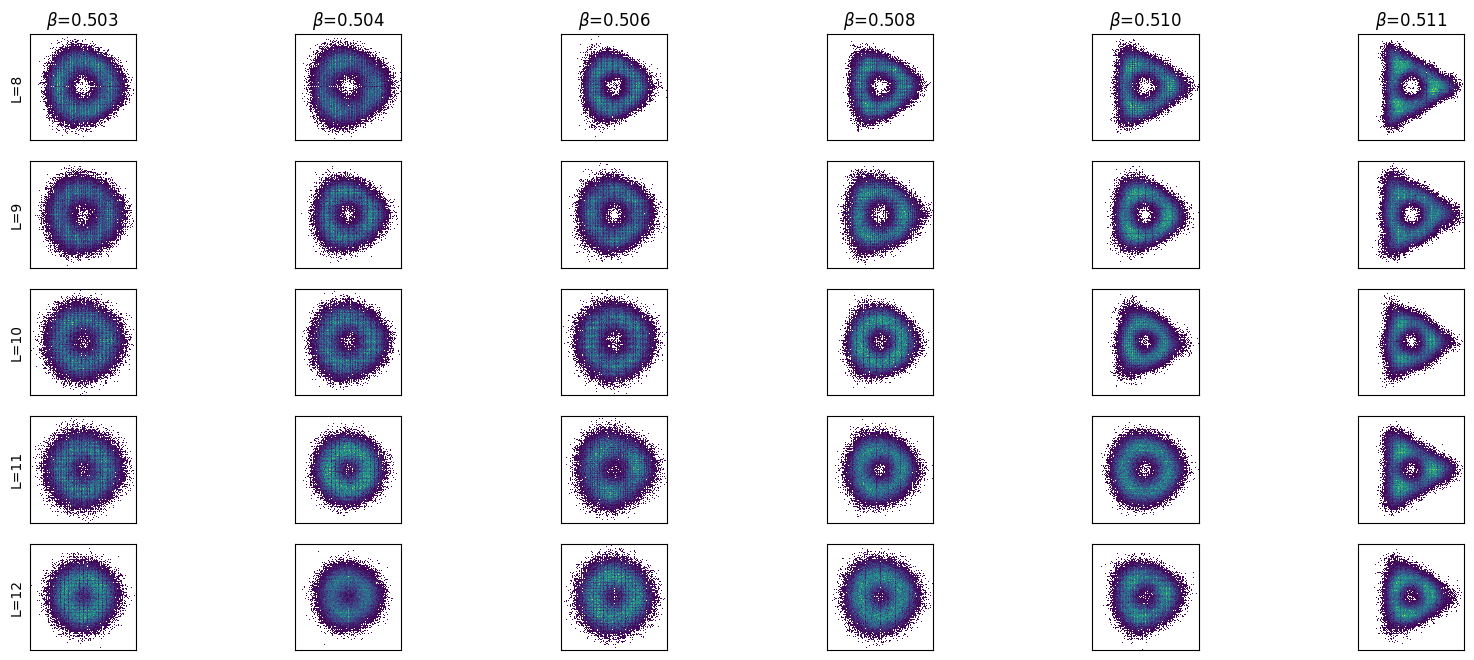

In [8]:
import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


rows = 5
colums = 6

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(rows, colums)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)


selected_betas = list(range(0, len(betas_list[0]), 1))
selected_betas = selected_betas[18:0:-1]
print(selected_betas)




for i in range(rows):
    for j in range(colums):

        time_serie = time_series_list[i, selected_betas[j]]

        cutoff = 200
        time_serie = time_serie[cutoff:]

        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        max_radius = np.max(np.linalg.norm(time_serie, axis=-1))

        radius = max_radius

        axes.append(fig.add_subplot(
            gs[i, colums -j -1], projection='scatter_density'))

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=200)

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].set_aspect('equal', 'box')
        axes[-1].set_xticks([])
        axes[-1].set_yticks([])
        # axes[-1].set_title(f"{index}")
        circle = plt.Circle((0, 0), 1, color='black', fill=False)
        axes[-1].add_artist(circle)

# Add title to columns
for i in range(colums):
    axes[i].set_title(r"$\beta$={:.3f}".format(
        betas_list[0][selected_betas[i]]))

# Add title to rows
for i in range(rows):
    axes[(i)*colums+ colums -1].set_ylabel(f"L={shapes_list[i]}")

# Save fig into z_n_gauge/data_analysis/figs
# plt.savefig('z_n_gauge/data_analysis/figs/triangle_to_circle/circles.pdf')

plt.savefig('cicles_scaling.pdf')

plt.show()
